In [1]:
import kagglehub

path = kagglehub.dataset_download(
    "smaranjitghose/corn-or-maize-leaf-disease-dataset"
)

print(path)

Using Colab cache for faster access to the 'corn-or-maize-leaf-disease-dataset' dataset.
/kaggle/input/corn-or-maize-leaf-disease-dataset


In [2]:
import os

for root, dirs, files in os.walk(path):
    print(root)

/kaggle/input/corn-or-maize-leaf-disease-dataset
/kaggle/input/corn-or-maize-leaf-disease-dataset/data
/kaggle/input/corn-or-maize-leaf-disease-dataset/data/Common_Rust
/kaggle/input/corn-or-maize-leaf-disease-dataset/data/Blight
/kaggle/input/corn-or-maize-leaf-disease-dataset/data/Healthy
/kaggle/input/corn-or-maize-leaf-disease-dataset/data/Gray_Leaf_Spot


In [3]:
DATASET = "/kaggle/input/corn-or-maize-leaf-disease-dataset/data"

In [4]:
import os

print(sorted(os.listdir(DATASET)))

['Blight', 'Common_Rust', 'Gray_Leaf_Spot', 'Healthy']


In [5]:
import tensorflow as tf
from tensorflow.keras.utils import image_dataset_from_directory

IMG_SIZE = (224,224)
BATCH_SIZE = 32

train_ds = image_dataset_from_directory(
    DATASET,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = image_dataset_from_directory(
    DATASET,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names

print(class_names)

Found 4188 files belonging to 4 classes.
Using 3351 files for training.
Found 4188 files belonging to 4 classes.
Using 837 files for validation.
['Blight', 'Common_Rust', 'Gray_Leaf_Spot', 'Healthy']


In [6]:
for images, labels in train_ds.take(1):
    print(images.shape)
    print(labels.shape)

(32, 224, 224, 3)
(32,)


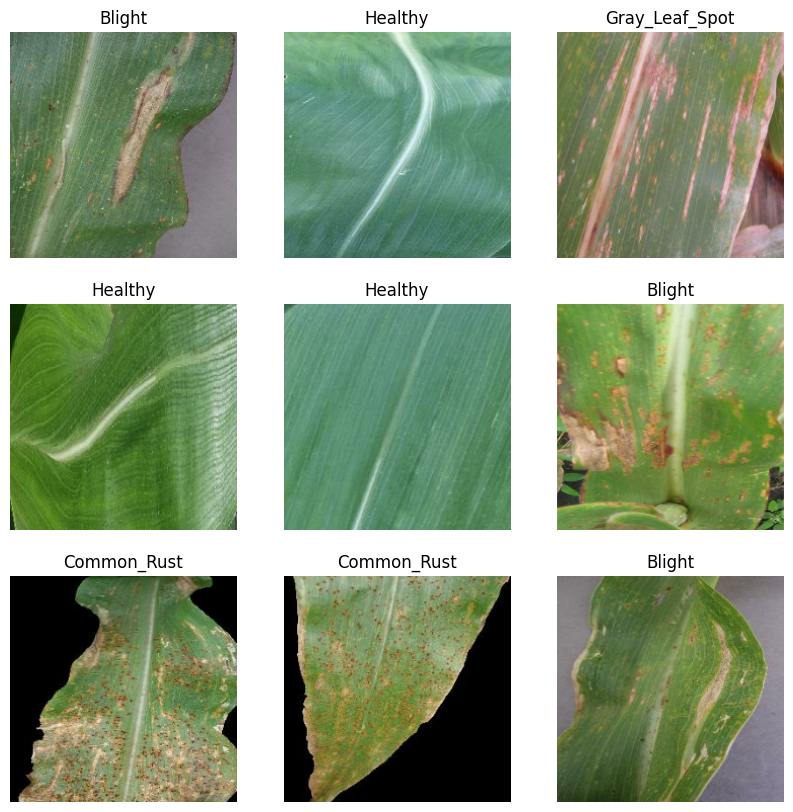

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):

    for i in range(9):

        ax = plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])

        plt.axis("off")

plt.show()

In [8]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)

In [9]:
from tensorflow.keras import layers
from tensorflow.keras import Model
from tensorflow.keras.applications import MobileNetV3Large

In [10]:
NUM_CLASSES = len(class_names)

base_model = MobileNetV3Large(
    input_shape=(224,224,3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

12683000/12683000 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [11]:
inputs = layers.Input(shape=(224,224,3))

x = layers.Rescaling(1./255)(inputs)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.3)(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

baseline_model = Model(inputs, outputs)

baseline_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Large (Functional)   │ (None, 7, 7, 960)      │     2,996,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 960)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 960)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         3,844 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,000,196 (11.44 MB)

 Trainable params: 3,844 (15.02 KB)

 Non-trainable params: 2,996,352 (11.43 MB)

In [12]:
baseline_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [13]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    )
]

In [14]:
history_baseline = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks
)

Epoch 1/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 166s 1s/step - accuracy: 0.3656 - loss: 1.3377 - val_accuracy: 0.5460 - val_loss: 1.2627
Epoch 2/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 132s 1s/step - accuracy: 0.4682 - loss: 1.2410 - val_accuracy: 0.4982 - val_loss: 1.2127
Epoch 3/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 155s 1s/step - accuracy: 0.5037 - loss: 1.1931 - val_accuracy: 0.5436 - val_loss: 1.1581
Epoch 4/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 132s 1s/step - accuracy: 0.5127 - loss: 1.1540 - val_accuracy: 0.5125 - val_loss: 1.1319
Epoch 5/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 132s 1s/step - accuracy: 0.5345 - loss: 1.1216 - val_accuracy: 0.5137 - val_loss: 1.1048
Epoch 6/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 133s 1s/step - accuracy: 0.5348 - loss: 1.1003 - val_accuracy: 0.6595 - val_loss: 1.0784
Epoch 7/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 130s 1s/step - accuracy: 0.5676 - loss: 1.0779 - val_accuracy: 0.5544 - val_loss: 1.0559
Epoch 8/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.5488 - loss: 1.0638 - val_accu

In [15]:
print(
    "Best Validation Accuracy:",
    max(history_baseline.history["val_accuracy"])
)

Best Validation Accuracy: 0.6594982147216797


In [16]:
print(max(history_baseline.history["accuracy"]))
print(max(history_baseline.history["val_accuracy"]))

0.5726648569107056
0.6594982147216797


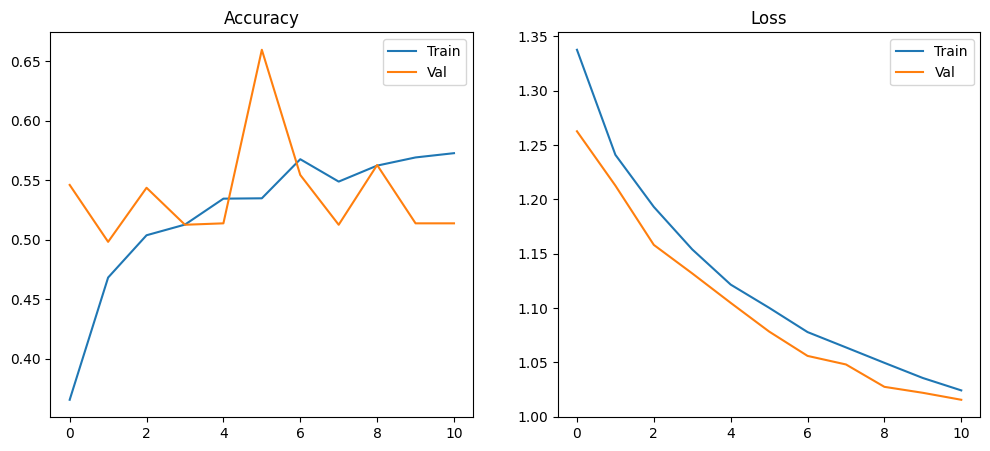

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_baseline.history['accuracy'])
plt.plot(history_baseline.history['val_accuracy'])
plt.title('Accuracy')
plt.legend(['Train','Val'])

plt.subplot(1,2,2)
plt.plot(history_baseline.history['loss'])
plt.plot(history_baseline.history['val_loss'])
plt.title('Loss')
plt.legend(['Train','Val'])

plt.show()

In [18]:
base_model.trainable = True

In [19]:
for layer in base_model.layers[:-30]:
    layer.trainable = False

In [20]:
baseline_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [21]:
history_ft = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks
)

Epoch 1/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 187s 2s/step - accuracy: 0.3262 - loss: 2.5520 - val_accuracy: 0.5699 - val_loss: 1.0838
Epoch 2/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 171s 2s/step - accuracy: 0.5697 - loss: 1.0156 - val_accuracy: 0.5556 - val_loss: 1.0782
Epoch 3/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 170s 2s/step - accuracy: 0.6210 - loss: 0.9128 - val_accuracy: 0.5556 - val_loss: 1.0794
Epoch 4/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 218s 2s/step - accuracy: 0.6514 - loss: 0.8564 - val_accuracy: 0.5042 - val_loss: 1.0996
Epoch 5/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 182s 2s/step - accuracy: 0.6941 - loss: 0.7925 - val_accuracy: 0.4803 - val_loss: 1.1548


In [22]:
print(max(history_ft.history["val_accuracy"]))

0.5698924660682678


In [23]:
baseline_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Large (Functional)   │ (None, 7, 7, 960)      │     2,996,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 960)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 960)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         3,844 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,197,326 (23.64 MB)

 Trainable params: 1,598,564 (6.10 MB)

 Non-trainable params: 1,401,632 (5.35 MB)

 Optimizer params: 3,197,130 (12.20 MB)

In [24]:
import numpy as np

y_train = np.concatenate([y.numpy() for x, y in train_ds], axis=0)
y_val   = np.concatenate([y.numpy() for x, y in val_ds], axis=0)

print("Train")
unique, counts = np.unique(y_train, return_counts=True)
for u,c in zip(unique, counts):
    print(class_names[u], ":", c)

print("\nValidation")
unique, counts = np.unique(y_val, return_counts=True)
for u,c in zip(unique, counts):
    print(class_names[u], ":", c)

Train
Blight : 921
Common_Rust : 1062
Gray_Leaf_Spot : 448
Healthy : 920

Validation
Blight : 225
Common_Rust : 244
Gray_Leaf_Spot : 126
Healthy : 242


In [26]:
import tensorflow as tf

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

In [27]:
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input

inputs = layers.Input(shape=(224,224,3))

x = data_augmentation(inputs)

x = preprocess_input(x)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.3)(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

baseline_model = Model(inputs, outputs)

In [28]:
base_model = MobileNetV3Large(
    input_shape=(224,224,3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

In [29]:
baseline_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Large (Functional)   │ (None, 7, 7, 960)      │     2,996,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 960)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 960)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         3,844 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,000,196 (11.44 MB)

 Trainable params: 1,598,564 (6.10 MB)

 Non-trainable params: 1,401,632 (5.35 MB)

In [30]:
print(base_model.trainable)

False
